| Поле | Значение |
|---|---|
| ФИО студента |Прокопович Д.А. |
| Группа | ИБАС-21 |
| Дата выполнения | 16.09.2026 |
| Номер варианта | 1 |
| Значение `SEED` (см. таблицу вариантов) | 42 |
| Преподаватель |Барулина М.А. и Скляренко М.С. |

| Признак | Цифровое возмущение | Патч на жёстком знаке | Состязательная одежда |
|---|---|---|---|
| Что изменяется | входной тензор модели (все пиксели, малые значения) | физический объект в сцене (наклейка/прямоугольник на знаке) | физический объект на теле человека (ткань с принтом) |
| Ограничение возмущения | \|δ\|_p ≤ ε, малая норма, часто все пиксели | носитель: локальная маска M (малая область), произвольные значения внутри | локальная маска на деформируемой поверхности, произвольный принт |
| Обязательные члены D | обычно только аддитивный шум (иногда лёгкие атаки на JPEG/сжатие) | ракурс (поворот), дистанция (масштаб), освещение, оптика (размытие), шум сенсора, окклюзии | всё из знака + **не-жёсткие деформации ткани (складки, растяжение), смена позы, самоокклюзия, динамика движения, материал и отражения** |
| Основная сложность | оптимизация в ε-шаре при известной модели | возмущение должно быть робастно ко ВСЕМ трансформациям съёмки одновременно (EOT), а не к малому шуму | трансформации не описываются жёсткой геометрией: поле деформаций нелинейно и меняется от кадра к кадру |
| Типичная метрика | ASR (доля обманутых примеров) при фиксированном ε | robust ASR: ASR по распределению физических условий (угол × дистанция), а не на одном кадре | robust ASR по кадрам видео/позам; доля кадров, где детектор обманут |

## Часть A. Стенд компьютерного зрения и базовая модель

Код подготовки данных дан полностью. **Ваша задача** — задать параметры своего варианта
и объяснить полученную точность.

In [1]:
# A.1: параметры варианта 1 из таблицы вариантов
SEED = 42    # вариант 1
RES = 16     # разрешение учебного сенсора
FREQ = 1.5   # частота складок ткани

assert SEED is not None and RES is not None and FREQ is not None, "Задайте параметры варианта"
print(f"Вариант 1: SEED={SEED}, RES={RES}, FREQ={FREQ}, углы части E: 0-32 с шагом 8")

Вариант 1: SEED=42, RES=16, FREQ=1.5, углы части E: 0-32 с шагом 8


RES = 16×16 | обучающая: 1257 | тестовая: 540
A.2 Базовая точность на неискажённых изображениях: 0.941


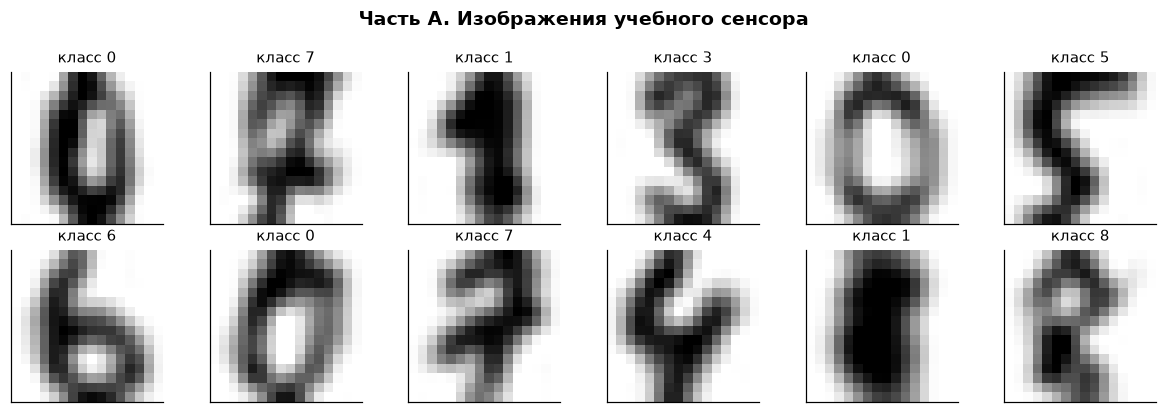

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy.ndimage import rotate, zoom, gaussian_filter, map_coordinates

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

rng = np.random.default_rng(SEED)

mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white",
})
PALETTE = {"clean": "#2E86AB", "mild": "#F2A541", "severe": "#D6455F",
           "robust": "#3FA46A", "accent": "#7B4FA0", "gray": "#8A94A6"}
CMAP_HEAT = LinearSegmentedColormap.from_list("acc", ["#7F1338", "#D6455F", "#F2A541", "#F7E463", "#3FA46A"])
CMAP_PATCH = ListedColormap(["#00B8A9"])


def show_img(ax, image, title=None):
    ax.imshow(image, cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    if title:
        ax.set_title(title, fontsize=9.5, fontweight="normal")


digits = load_digits()
raw = digits.images.astype(np.float32) / 16.0
images = np.clip(np.asarray([gaussian_filter(zoom(im, RES / 8.0, order=3), 0.6) for im in raw]), 0, 1).astype(np.float32)
labels = digits.target

X_train_img, X_test_img, y_train, y_test = train_test_split(
    images, labels, test_size=0.30, stratify=labels, random_state=SEED)


def flat(arr3d):
    return np.asarray(arr3d).reshape(len(arr3d), -1)


# Признаки — интенсивности пикселей в [0, 1]; масштабирование по дисперсии не применяется,
# иначе всегда нулевые краевые пиксели дают численные артефакты при сдвиге условий съёмки.
baseline = LogisticRegression(max_iter=4000, C=0.05, random_state=SEED).fit(flat(X_train_img), y_train)
acc_clean = accuracy_score(y_test, baseline.predict(flat(X_test_img)))
print(f"RES = {RES}×{RES} | обучающая: {len(X_train_img)} | тестовая: {len(X_test_img)}")
print(f"A.2 Базовая точность на неискажённых изображениях: {acc_clean:.3f}")

fig, axes = plt.subplots(2, 6, figsize=(11, 3.8))
for ax, im, lb in zip(axes.ravel(), X_train_img[:12], y_train[:12]):
    show_img(ax, im, f"класс {lb}")
fig.suptitle("Часть A. Изображения учебного сенсора", fontsize=12.5, fontweight="bold")
plt.tight_layout()
plt.show()

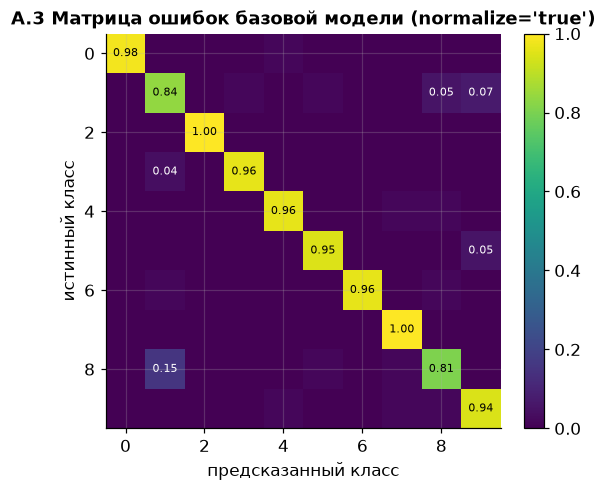

A.3 Наибольшая путаница: класс 8 путается с 1: 0.154
A.3 Наибольшая путаница: класс 1 путается с 9: 0.073


In [3]:
# A.3: нормированная матрица ошибок базовой модели
y_pred_base = baseline.predict(flat(X_test_img))
cm = confusion_matrix(y_test, y_pred_base, normalize="true")

fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(cm, cmap="viridis")
ax.set_xlabel("предсказанный класс"); ax.set_ylabel("истинный класс")
ax.set_title("A.3 Матрица ошибок базовой модели (normalize='true')")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j] > 0.02:
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if cm[i, j] < 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

off = cm.copy(); np.fill_diagonal(off, 0.0)
top2 = np.dstack(np.unravel_index(np.argsort(off.ravel())[::-1][:2], off.shape))[0]
for i, j in top2:
    print(f"A.3 Наибольшая путаница: класс {i} путается с {j}: {off[i, j]:.3f}")

| Показатель | Ваше значение |
|---|---|
| `SEED` / `RES` | 42 / 16 (вариант 1, FREQ = 1.5) |
| Размер обучающей выборки | 1257 |
| Базовая точность `acc_clean` | 0.941 |
| Две пары классов с наибольшей путаницей | 8 → 1 (0.154) и 1 → 9 (0.073) |

**Вопрос A.** Можно ли по значению `acc_clean` судить о пригодности модели для работы
с физическими объектами? Обоснуйте.

Ответ: **Нет.** `acc_clean = 0.941` измерена на *цифровых* изображениях — идеальной,
бесшумной копии сенсора: без поворотов, дистанции, освещения, оптики и окклюзий. Физическая
съёмка добавляет преобразование $T_\theta$ со случайными параметрами $\theta$, и, как
показывает часть D, уже при умеренных условиях точность падает до 0.739, при сильных — до
0.485 (а при повороте 24–32° — до 0.109–0.28). Т.е. пригодность модели определяется не
точностью на чистых данных, а точностью **по распределению физических условий**
(robust accuracy / EOT-оценка). Высокий `acc_clean` — необходимое, но не достаточное условие:
он лишь фиксирует «верхнюю границу», которая в реальном канале наблюдения почти не
реализуется.

## Часть B. Имитация физического канала

Функция `resize_to_shape` дана. **Ваша задача** — дописать `physical_transform`: реализовать
изменение яркости и контраста, размытие, шум сенсора и окклюзию.

In [4]:
def resize_to_shape(image, shape):
    out = np.zeros(shape, dtype=np.float32)
    h = min(shape[0], image.shape[0]); w = min(shape[1], image.shape[1])
    ts, ls = max((image.shape[0] - h) // 2, 0), max((image.shape[1] - w) // 2, 0)
    td, ld = max((shape[0] - h) // 2, 0), max((shape[1] - w) // 2, 0)
    out[td:td + h, ld:ld + w] = image[ts:ts + h, ls:ls + w]
    return out

In [5]:
def physical_transform(image, angle=0.0, scale=1.0, brightness=1.0, contrast=1.0,
                       blur=0.0, noise=0.0, occlusion=None, generator=None):
    """Имитация физического канала наблюдения объекта камерой."""
    gen = generator if generator is not None else rng

    # поворот и масштаб уже реализованы
    out = rotate(image, angle=angle, reshape=False, order=1, mode="constant", cval=0.0)
    if abs(scale - 1.0) > 1e-6:
        out = resize_to_shape(zoom(out, scale, order=1), image.shape)

    # B.1: контраст относительно середины диапазона
    if abs(contrast - 1.0) > 1e-6:
        out = (out - 0.5) * contrast + 0.5
    # B.2: яркость — умножение на brightness
    if abs(brightness - 1.0) > 1e-6:
        out = out * brightness
    # B.3: размытие оптики
    if blur > 0:
        out = gaussian_filter(out, sigma=blur)
    # B.4: шум сенсора
    if noise > 0:
        out = out + gen.normal(0.0, noise, out.shape)
    # B.5: окклюзия (r0, r1, c0, c1, value)
    if occlusion is not None:
        r0, r1, c0, c1, value = occlusion
        out[r0:r1, c0:c1] = value

    return np.clip(out, 0.0, 1.0).astype(np.float32)

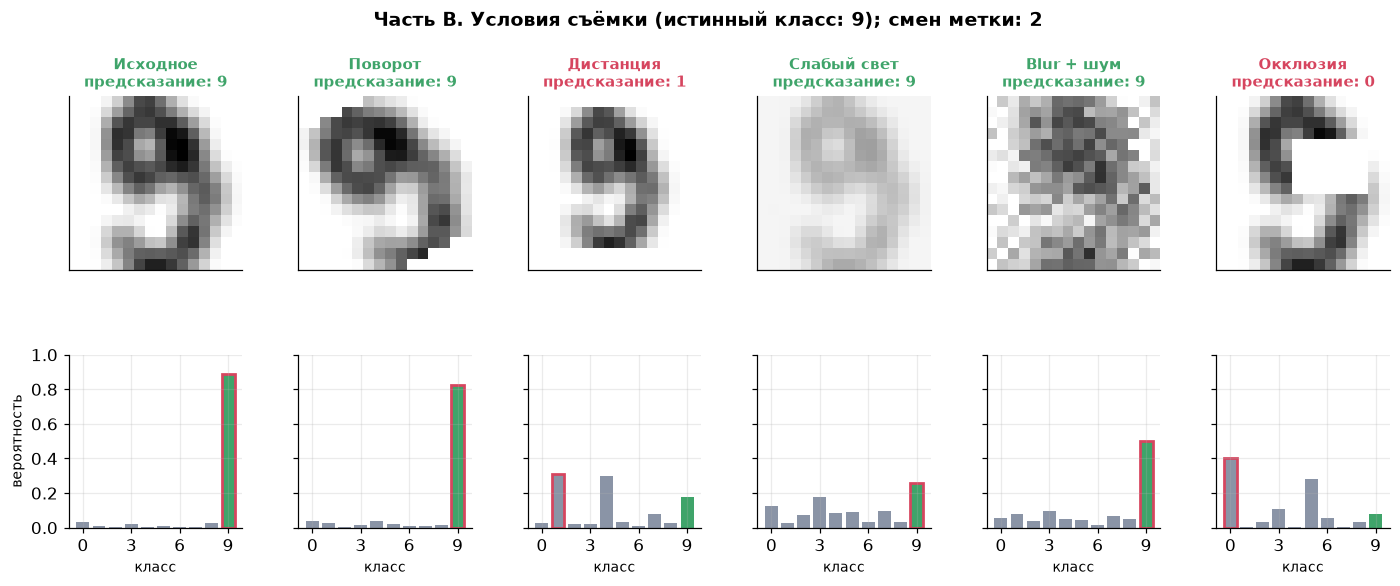

B.7 Число режимов со сменой метки: 2 (требуется не менее 2)
B.8 Строки отчётной таблицы (истинный класс 9):
| Исходное | 9 | 0.891 | нет |
| Поворот | 9 | 0.826 | нет |
| Дистанция | 1 | 0.175 | да |
| Слабый свет | 9 | 0.255 | нет |
| Blur + шум | 9 | 0.502 | нет |
| Окклюзия | 0 | 0.080 | да |


In [6]:
# B.6: объект-пример и условия съёмки (минимум два режима должны менять метку)
idx = 9
example, true_label = X_test_img[idx], y_test[idx]

conditions = [
    ("Исходное",        dict()),
    ("Поворот",         dict(angle=26)),
    ("Дистанция",       dict(scale=0.80)),
    ("Слабый свет",     dict(brightness=0.42, contrast=0.80)),
    ("Blur + шум",      dict(blur=1.7, noise=0.13)),
    ("Окклюзия",        dict(occlusion=(RES // 4, RES // 4 + RES // 3, RES // 2 - 1, RES - 2, 0.0))),
]

fig, axes = plt.subplots(2, len(conditions), figsize=(15.5, 5.4),
                         gridspec_kw={"height_ratios": [1.3, 1], "hspace": 0.30, "wspace": 0.32})
flips = 0
report_b = []
for col, (name, params) in enumerate(conditions):
    view = physical_transform(example, **params, generator=np.random.default_rng(SEED + col))
    proba = baseline.predict_proba(flat(view[None, ...]))[0]
    pred = int(np.argmax(proba)); ok = pred == true_label
    flips += (not ok)
    report_b.append((name, pred, float(proba[true_label]), not ok))
    show_img(axes[0, col], view)
    axes[0, col].set_title(f"{name}\nпредсказание: {pred}", fontsize=9.5, fontweight="bold",
                           color=PALETTE["robust"] if ok else PALETTE["severe"])
    bars = axes[1, col].bar(range(10), proba,
                            color=[PALETTE["robust"] if k == true_label else PALETTE["gray"] for k in range(10)])
    bars[pred].set_edgecolor(PALETTE["severe"]); bars[pred].set_linewidth(1.8)
    axes[1, col].set_ylim(0, 1); axes[1, col].set_xticks(range(0, 10, 3))
    axes[1, col].set_xlabel("класс", fontsize=9)
    if col == 0:
        axes[1, col].set_ylabel("вероятность", fontsize=9)
    else:
        axes[1, col].set_yticklabels([])
fig.suptitle(f"Часть B. Условия съёмки (истинный класс: {true_label}); смен метки: {flips}",
             fontsize=12.5, fontweight="bold")
plt.show()
print(f"B.7 Число режимов со сменой метки: {flips} (требуется не менее 2)")
print(f"B.8 Строки отчётной таблицы (истинный класс {true_label}):")
for name, pred, p_true, changed in report_b:
    print(f"| {name} | {pred} | {p_true:.3f} | {'да' if changed else 'нет'} |")

| Режим | Предсказание | Вероятность истинного класса | Метка изменилась? |
|---|---|---|---|
| Исходное | 9 | 0.891 | нет |
| Поворот | 9 | 0.826 | нет |
| Дистанция | 1 | 0.175 | **да** |
| Слабый свет | 9 | 0.255 | нет |
| Blur + шум | 9 | 0.502 | нет |
| Окклюзия | 0 | 0.080 | **да** |

(объект-пример: индекс 9, истинный класс 9; смен метки: 2 — требование выполнено)

**Вопрос B.** Какой фактор в вашем эксперименте оказался наиболее разрушительным и почему?
Отличается ли ответ для другого объекта-примера?

Ответ: **Наиболее разрушительными оказались окклюзия и дистанция** — единственные два режима,
сменившие метку (9 → 0 при окклюзии с вероятностью истинного класса 0.080; 9 → 1 при
уменьшении масштаба до 0.80 с вероятностью 0.175). Механизм разный: **окклюзия** физически
стирает информативную часть цифры (нижние 2/3 правой половины кадра занулены) — модель теряет
признаки, по которым она отличает 9 от других классов, и уверенно переключается на 0;
**дистанция** (scale 0.80) уменьшает видимую площадь цифры и после обратной нормировки кадра
«размывает» штрихи — тонкие элементы (хвостик девятки) теряются, и конфигурация становится
похожей на единицу. Поворот 26° и слабый свет снизили уверенность (0.826 и 0.255), но метку
не сменили: у 9 есть запас прочности по этим факторам. Для другого объекта-примера ответ
может отличаться: у каждого класса свой запас уверенности и свои «уязвимые» факторы
(например, для 1 поворот, скорее всего, безвреден, а вот для 8/6 — разрушителен из-за
симметрии), поэтому выводы о физической хрупкости всегда нужно проверять на нескольких
объектах и по распределению условий (как в части D).

## Часть C. Локальный патч: площадь и положение

**Ваша задача** — реализовать наложение локального маркера, построить карту точности по позициям
и кривую деградации по занимаемой площади.

> В работе используется **нейтральный маркер**, а не оптимизированный патч: исследуется структура
> ограничения (маска, площадь, положение), а не создание атакующего шаблона.

In [7]:
def apply_marker(image, top=0, left=0, size=None, value=0.9):
    """Возвращает (изображение с маркером, бинарную маску маркера)."""
    if size is None:
        size = max(3, RES // 3)
    # C.1: вписать value в окно [top:top+size, left:left+size] и построить маску
    result = image.copy()
    mask = np.zeros_like(image, dtype=np.float32)
    result[top:top + size, left:left + size] = value
    mask[top:top + size, left:left + size] = 1.0
    return result, mask

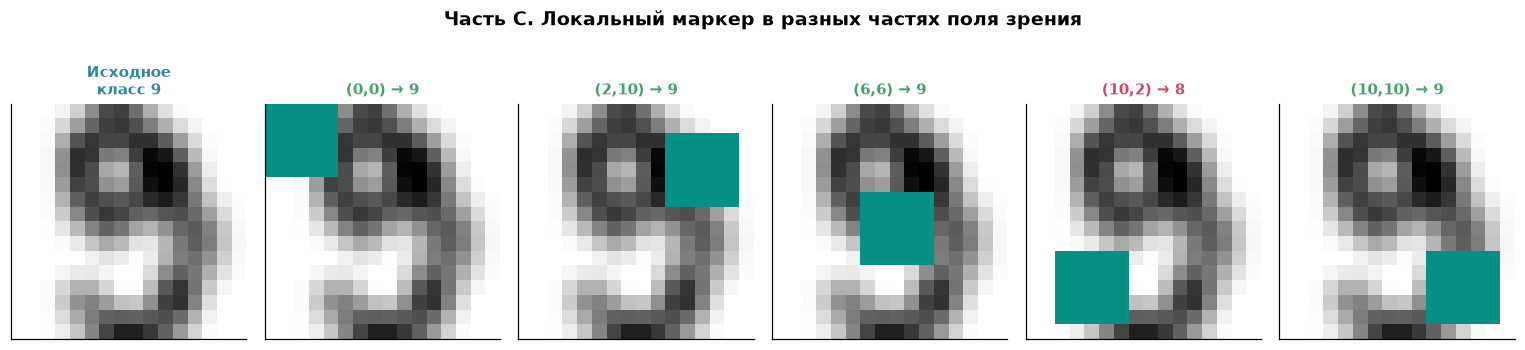

In [8]:
MARKER = max(3, RES // 3)   # сторона маркера
positions = [(0, 0), (2, RES - MARKER - 1), (RES // 2 - 2, RES // 2 - 2),
             (RES - MARKER - 1, 2), (RES - MARKER - 1, RES - MARKER - 1)]

fig, axes = plt.subplots(1, len(positions) + 1, figsize=(14, 2.9))
show_img(axes[0], example)
axes[0].set_title(f"Исходное\nкласс {true_label}", fontsize=9.5, fontweight="bold", color=PALETTE["clean"])
for ax, (top, left) in zip(axes[1:], positions):
    marked, mask = apply_marker(example, top, left, MARKER)
    pred = int(baseline.predict(flat(marked[None, ...]))[0])
    show_img(ax, marked)
    ax.imshow(np.ma.masked_where(mask == 0, mask), cmap=CMAP_PATCH, vmin=0, vmax=1,
              alpha=0.75, interpolation="nearest")
    ax.set_title(f"({top},{left}) → {pred}", fontsize=9.5, fontweight="bold",
                 color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])
fig.suptitle("Часть C. Локальный маркер в разных частях поля зрения",
             fontsize=12.5, fontweight="bold", y=1.10)
plt.tight_layout()
plt.show()

In [9]:
# C.2: карта точности по позициям маркера на всей тестовой выборке
# C.3: кривая деградации по площади маркера

stride = max(1, RES // 8)
grid_pos = list(range(0, RES - MARKER + 1, stride))
pos_map = np.zeros((len(grid_pos), len(grid_pos)))
for i, r in enumerate(grid_pos):
    for j, c in enumerate(grid_pos):
        marked_test = np.asarray([apply_marker(im, r, c, MARKER)[0] for im in X_test_img])
        pos_map[i, j] = accuracy_score(y_test, baseline.predict(flat(marked_test)))

sizes = [0, RES // 8, RES // 5, RES // 4, RES // 3, RES // 2, int(RES * 0.7)]
area_acc, area_frac = [], []
for s in sizes:
    if s == 0:
        area_acc.append(acc_clean)
        area_frac.append(0.0)
        continue
    marked_test = np.asarray([apply_marker(im, (RES - s) // 2, (RES - s) // 2, s)[0]
                              for im in X_test_img])
    area_acc.append(accuracy_score(y_test, baseline.predict(flat(marked_test))))
    area_frac.append(100.0 * s * s / RES ** 2)

print("C.6 Кривая деградации по площади (строки отчёта):")
for s, fr, ac in zip(sizes, area_frac, area_acc):
    print(f"  сторона {s:2d} px ({fr:5.1f}% кадра): accuracy = {ac:.3f}")
below = next((fr for fr, ac in zip(area_frac, area_acc) if ac < 0.5), None)
print(f"C.7 Accuracy падает ниже 0.5 при доле площади: {below:.1f}%" if below is not None
      else "C.7 Accuracy не падает ниже 0.5 ни при одной из исследованных площадей")

C.6 Кривая деградации по площади (строки отчёта):
  сторона  0 px (  0.0% кадра): accuracy = 0.941
  сторона  2 px (  1.6% кадра): accuracy = 0.941
  сторона  3 px (  3.5% кадра): accuracy = 0.922
  сторона  4 px (  6.2% кадра): accuracy = 0.833
  сторона  5 px (  9.8% кадра): accuracy = 0.785
  сторона  8 px ( 25.0% кадра): accuracy = 0.422
  сторона 11 px ( 47.3% кадра): accuracy = 0.189
C.7 Accuracy падает ниже 0.5 при доле площади: 25.0%


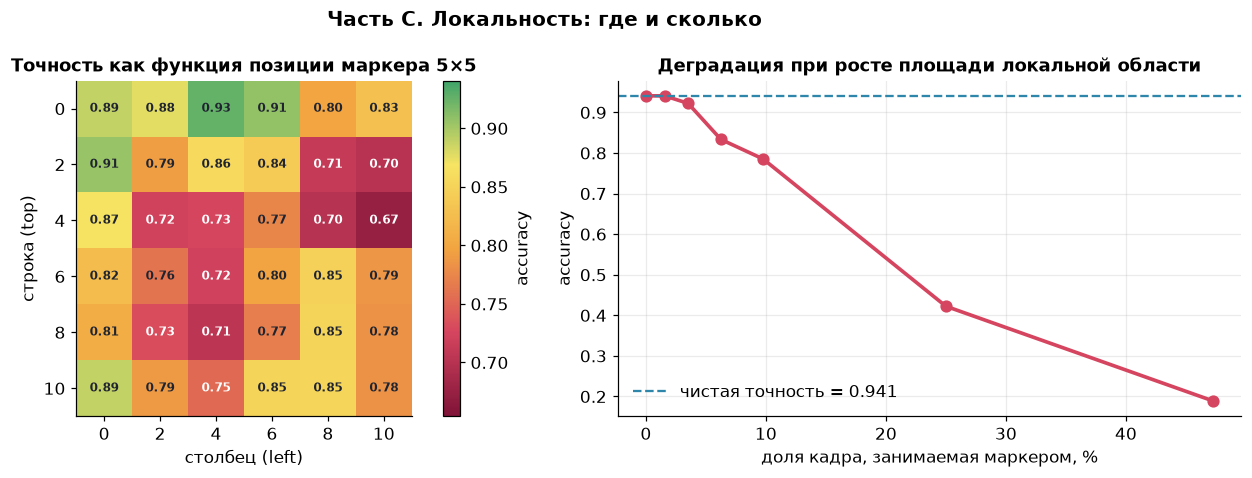

C.4 Худшая позиция: (4, 10) → accuracy 0.674
C.5 Лучшая позиция: accuracy 0.926; разница 0.252


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
im = axes[0].imshow(pos_map, cmap=CMAP_HEAT, vmin=pos_map.min() - 0.02, vmax=acc_clean)
axes[0].set_title(f"Точность как функция позиции маркера {MARKER}×{MARKER}")
axes[0].set_xlabel("столбец (left)"); axes[0].set_ylabel("строка (top)"); axes[0].grid(False)
axes[0].set_xticks(range(len(grid_pos))); axes[0].set_xticklabels(grid_pos)
axes[0].set_yticks(range(len(grid_pos))); axes[0].set_yticklabels(grid_pos)
for i in range(pos_map.shape[0]):
    for j in range(pos_map.shape[1]):
        axes[0].text(j, i, f"{pos_map[i, j]:.2f}", ha="center", va="center", fontsize=8,
                     fontweight="bold", color="white" if pos_map[i, j] < 0.76 else "#1F2430")
fig.colorbar(im, ax=axes[0], fraction=0.046, label="accuracy")

axes[1].plot(area_frac, area_acc, "o-", color=PALETTE["severe"], linewidth=2.4, markersize=7)
axes[1].axhline(acc_clean, ls="--", color=PALETTE["clean"], label=f"чистая точность = {acc_clean:.3f}")
axes[1].set_xlabel("доля кадра, занимаемая маркером, %"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Деградация при росте площади локальной области")
axes[1].legend(frameon=False)
fig.suptitle("Часть C. Локальность: где и сколько", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

worst = np.unravel_index(np.argmin(pos_map), pos_map.shape)
print(f"C.4 Худшая позиция: ({grid_pos[worst[0]]}, {grid_pos[worst[1]]}) → accuracy {pos_map.min():.3f}")
print(f"C.5 Лучшая позиция: accuracy {pos_map.max():.3f}; разница {pos_map.max() - pos_map.min():.3f}")

| Показатель | Ваше значение |
|---|---|
| Сторона маркера `MARKER` | 5 px (RES // 3 = 5, 9.8% кадра) |
| Худшая позиция и её accuracy | (4, 10) → 0.674 |
| Лучшая позиция и её accuracy | 0.926 |
| Разница между худшей и лучшей позицией | 0.252 |
| Площадь, при которой accuracy падает ниже 0.5, % | 25.0% (маркер 8×8 px) |

Кривая деградации по площади (маркер в центре кадра): 0% → 0.941; 1.6% (2 px) → 0.941;
3.5% (3 px) → 0.922; 6.2% (4 px) → 0.833; 9.8% (5 px) → 0.785; 25.0% (8 px) → 0.422;
47.3% (11 px) → 0.189.

**Вопрос C.** Почему при одинаковой площади результат зависит от положения области?
Свяжите ответ с тем, какие части объекта информативны для модели.

Ответ: **Потому что пиксели изображения информативны неравномерно, а логистическая регрессия
опирается на конкретные взвешенные комбинации пикселей.** Информация о классе цифры
сосредоточена в штрихах — «несущей конструкции» символа (для 9 — замкнутый круг сверху и
хвост справа-снизу). Маркер 5×5 в позиции (4, 10) попадает в нижнюю центральную зону, где
проходят хвосты/вертикальные штрихи большинства цифр: перекрытие этой области ломает сразу
много дискриминативных признаков (accuracy 0.674). Та же по площади область в углу кадра
(например, левый верхний угол) почти всегда лежит на пустом фоне — модель теряет лишь
«нулевые» признаки с малыми весами, и accuracy остаётся 0.926. Разница 0.252 при одинаковой
площади — прямое следствие того, что **эффективность патча определяется не его размером, а
тем, какую долю информативного контента объекта он перекрывает**. Отсюда практический вывод
для физических атак: патч следует размещать на информативных частях объекта, а для защиты —
контролировать целостность именно информативных зон (и обучать модель на аугментациях с
окклюзиями, как в части G).

## Часть D. Expectation over Transformation

**Ваша задача** — реализовать выборку параметров съёмки, оценить точность многократно
и сравнить разброс между режимами.

In [11]:
def sample_params(gen, severity=1.0):
    """Случайные параметры съёмки; severity масштабирует весь диапазон условий."""
    # D.1: диапазоны при severity = 1: angle ±17°, scale 0.83-1.13, brightness 0.74-1.20,
    #      contrast 0.80-1.20, blur 0-0.85, noise 0-0.055
    return {
        "angle": gen.uniform(-17.0, 17.0) * severity,
        "scale": 1.0 + gen.uniform(-0.17, 0.13) * severity,
        "brightness": 1.0 + gen.uniform(-0.26, 0.20) * severity,
        "contrast": 1.0 + gen.uniform(-0.20, 0.20) * severity,
        "blur": gen.uniform(0.0, 0.85) * severity,
        "noise": gen.uniform(0.0, 0.055) * severity,
    }


def transformed_dataset(imgs, gen, severity=1.0):
    # D.2: применить physical_transform со случайными параметрами к каждому изображению
    return np.asarray([physical_transform(im, generator=gen, **sample_params(gen, severity))
                       for im in imgs])

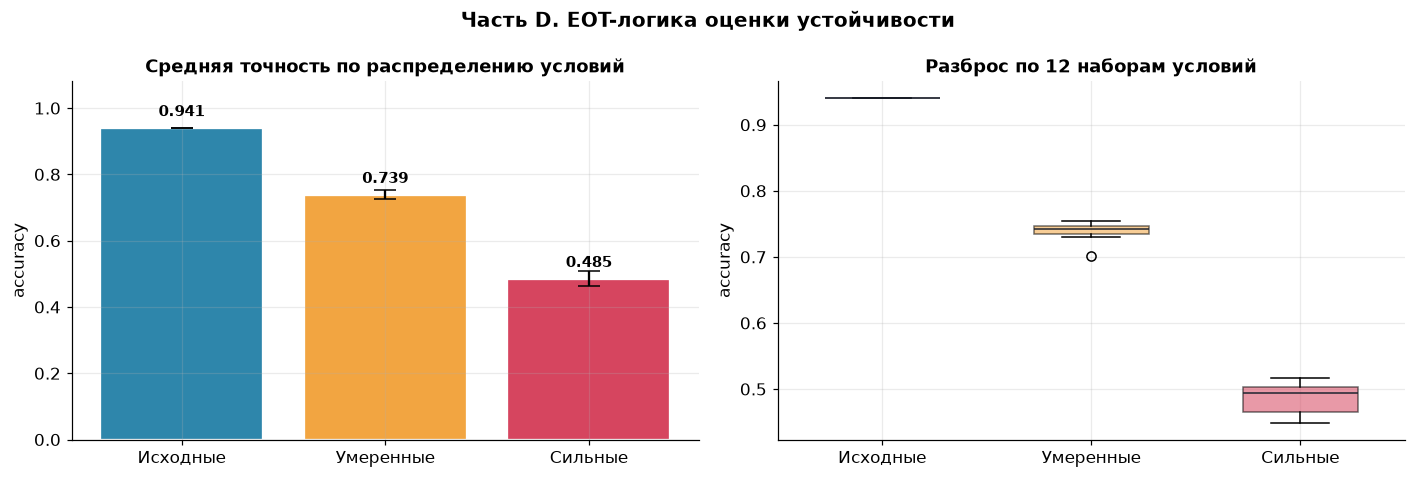

D.3 Исходные   accuracy = 0.941 ± 0.000
D.3 Умеренные  accuracy = 0.739 ± 0.014
D.3 Сильные    accuracy = 0.485 ± 0.022


In [12]:
REPEATS = 12
regimes = [("Исходные", 0.0, PALETTE["clean"]),
           ("Умеренные", 1.0, PALETTE["mild"]),
           ("Сильные", 1.8, PALETTE["severe"])]

samples = {}
for name, sev, _ in regimes:
    gen = np.random.default_rng(SEED + 1000)
    if sev == 0.0:
        samples[name] = [acc_clean] * REPEATS
    else:
        samples[name] = [accuracy_score(y_test, baseline.predict(flat(transformed_dataset(X_test_img, gen, sev))))
                         for _ in range(REPEATS)]

names = [n for n, _, _ in regimes]
means = [float(np.mean(samples[n])) for n in names]
stds = [float(np.std(samples[n])) for n in names]
colors = [c for _, _, c in regimes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
bars = axes[0].bar(names, means, yerr=stds, capsize=7, color=colors, edgecolor="white", linewidth=1.5)
for b, v in zip(bars, means):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.035, f"{v:.3f}", ha="center", fontsize=9.5, fontweight="bold")
axes[0].set_ylim(0, 1.08); axes[0].set_ylabel("accuracy")
axes[0].set_title("Средняя точность по распределению условий")

bp = axes[1].boxplot([samples[n] for n in names], patch_artist=True, widths=0.55,
                     medianprops=dict(color="#1F2430"))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.55)
axes[1].set_xticks(range(1, len(names) + 1)); axes[1].set_xticklabels(names)
axes[1].set_ylabel("accuracy"); axes[1].set_title(f"Разброс по {REPEATS} наборам условий")
fig.suptitle("Часть D. EOT-логика оценки устойчивости", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

for n, m, s in zip(names, means, stds):
    print(f"D.3 {n:<10} accuracy = {m:.3f} ± {s:.3f}")

| Режим | Средняя accuracy | Стандартное отклонение | Падение относительно `acc_clean` |
|---|---|---|---|
| Исходные | 0.941 | 0.000 | — |
| Умеренные | 0.739 | 0.014 | −0.202 |
| Сильные | 0.485 | 0.022 | −0.456 |

**Вопрос D.** Почему оценка по одному кадру может завысить устойчивость модели?
Как связаны величина `severity` и стандартное отклонение?

Ответ: **Один кадр — одна реализация случайных параметров съёмки $\theta \sim \mathcal{D}$.**
Если повезло с ракурсом/освещением, модель ответит верно, и наблюдатель ошибочно заключит,
что она устойчива; но соседняя реализация (другой угол, чуть сильнее размытие) может сменить
метку. Именно это показывает часть B: на одном объекте часть режимов безвредна, часть —
разрушительна. Корректная оценка — **усреднение по распределению условий (EOT)**: 12 наборов
условий дали среднее 0.739 ± 0.014 при умеренной жёсткости — на 0.20 ниже «идеального»
значения, которое дала бы оценка по одному чистому кадру. **Связь severity и разброса:**
с ростом жёсткости условий растёт и среднее падение (0.941 → 0.739 → 0.485), и абсолютный
разброс между реализациями (σ: 0.000 → 0.014 → 0.022): при сильном severity модель чаще
оказывается вблизи границы решения, где исход (верно/неверно) чувствителен к конкретной
реализации $\theta$, поэтому отдельные наборы условий дают сильно разные результаты.
Разброс — не шум измерения, а реальная мера неоднородности качества модели по условиям
съёмки; пренебрежение им и есть причина завышения устойчивости при оценке по одному кадру.

## Часть E. Дорожный знак: дистанция и ракурс

**Ваша задача** — построить карту точности в координатах «масштаб × угол» для набора углов
своего варианта и определить границу применимости модели.

In [13]:
# E.1: углы варианта 1 — 0-32° с шагом 8°
scales = [1.10, 1.00, 0.94, 0.88, 0.82, 0.76]
angles = [0, 8, 16, 24, 32]

# E.2: матрица grid — строки углы, столбцы масштабы (детерминированный gen на ячейку)
grid = np.zeros((len(angles), len(scales)))
for i, a in enumerate(angles):
    for j, s in enumerate(scales):
        gen = np.random.default_rng(SEED + 7)
        views = np.asarray([physical_transform(im, angle=a, scale=s, generator=gen)
                            for im in X_test_img])
        grid[i, j] = accuracy_score(y_test, baseline.predict(flat(views)))

print(f"E.4 Максимальная accuracy в карте: {grid.max():.3f} "
      f"(угол {angles[grid.max(0).argmax()]}°, масштаб x{scales[grid.max(1).argmax()]})")
print(f"E.5 Минимальная accuracy в карте: {grid.min():.3f}")
for i, a in enumerate(angles):
    ok = [f"x{s:.2f}={grid[i, j]:.2f}" for j, s in enumerate(scales) if grid[i, j] >= 0.70]
    print(f"   {a:>3}°: допустимые масштабы: {', '.join(ok) if ok else 'нет'}")

E.4 Максимальная accuracy в карте: 0.941 (угол 8°, масштаб x1.1)
E.5 Минимальная accuracy в карте: 0.109
     0°: допустимые масштабы: x1.10=0.92, x1.00=0.94, x0.94=0.89, x0.88=0.83
     8°: допустимые масштабы: x1.10=0.88, x1.00=0.89, x0.94=0.81
    16°: допустимые масштабы: x1.10=0.77, x1.00=0.79
    24°: допустимые масштабы: нет
    32°: допустимые масштабы: нет


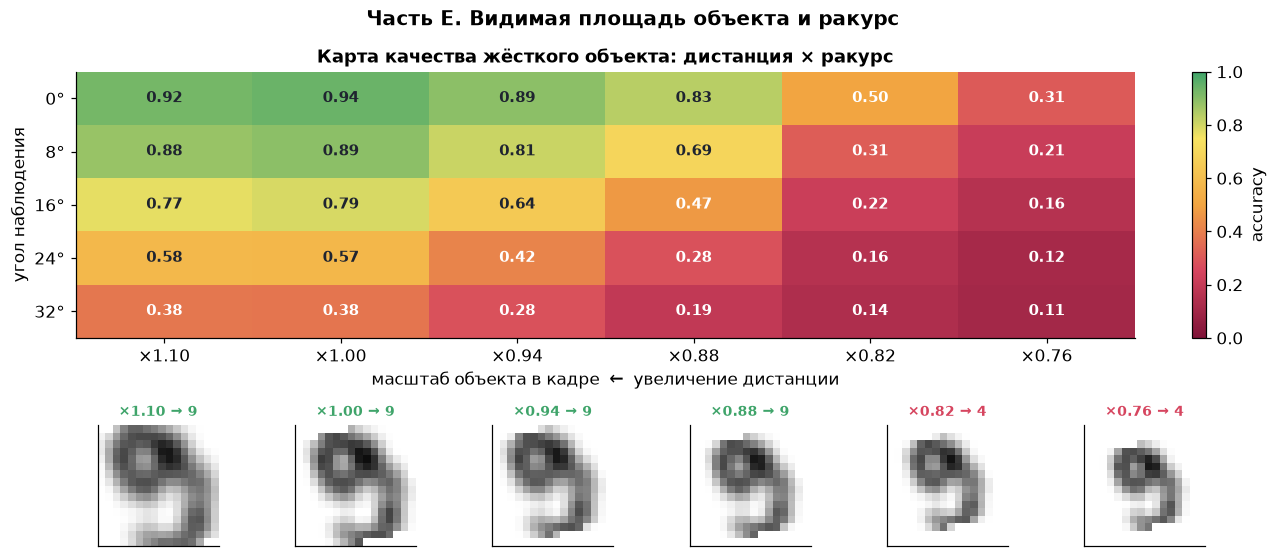

E.3 Режимы с accuracy >= 0.70:
     0°: ×1.10, ×1.00, ×0.94, ×0.88
     8°: ×1.10, ×1.00, ×0.94
    16°: ×1.10, ×1.00
    24°: нет
    32°: нет


In [14]:
fig = plt.figure(figsize=(13.5, 5.6))
gs = fig.add_gridspec(2, len(scales), height_ratios=[2.2, 1.0], hspace=0.45)

ax = fig.add_subplot(gs[0, :])
im = ax.imshow(grid, cmap=CMAP_HEAT, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(scales))); ax.set_xticklabels([f"×{s:.2f}" for s in scales])
ax.set_yticks(range(len(angles))); ax.set_yticklabels([f"{a}°" for a in angles])
ax.set_xlabel("масштаб объекта в кадре  ←  увеличение дистанции")
ax.set_ylabel("угол наблюдения"); ax.grid(False)
ax.set_title("Карта качества жёсткого объекта: дистанция × ракурс")
for i in range(len(angles)):
    for j in range(len(scales)):
        ax.text(j, i, f"{grid[i, j]:.2f}", ha="center", va="center", fontsize=9.5,
                fontweight="bold", color="white" if grid[i, j] < 0.55 else "#1F2430")
fig.colorbar(im, ax=ax, fraction=0.03, label="accuracy")

for j, s in enumerate(scales):
    axf = fig.add_subplot(gs[1, j])
    view = physical_transform(example, angle=angles[len(angles) // 2], scale=s, brightness=0.95,
                              blur=0.25, generator=np.random.default_rng(SEED))
    pred = int(baseline.predict(flat(view[None, ...]))[0])
    show_img(axf, view)
    axf.set_title(f"×{s:.2f} → {pred}", fontsize=9, fontweight="bold",
                  color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])
fig.suptitle("Часть E. Видимая площадь объекта и ракурс", fontsize=13, fontweight="bold")
plt.show()

mask_ok = grid >= 0.70
print("E.3 Режимы с accuracy >= 0.70:")
for i, a in enumerate(angles):
    ok = [f"×{s:.2f}" for j, s in enumerate(scales) if mask_ok[i, j]]
    print(f"   {a:>3}°: {', '.join(ok) if ok else 'нет'}")

| Показатель | Ваше значение |
|---|---|
| Углы варианта | 0, 8, 16, 24, 32° (вариант 1, шаг 8°) |
| Максимальная accuracy в карте | 0.941 (угол 8°, масштаб ×1.10) |
| Минимальная accuracy в карте | 0.109 (угол 32°, масштаб ×0.76) |
| Наибольший допустимый угол при accuracy ≥ 0.70 | 16° (при масштабах ×1.10 и ×1.00) |
| Наименьший допустимый масштаб при accuracy ≥ 0.70 | ×0.88 (при угле 0°) |

**Вопрос E.** Как связаны видимая площадь знака в кадре и успех физической атаки?
Чем отличается атака на классификатор от атаки на детектор в конвейере автономного вождения?

Ответ: **Видимая площадь и успех атаки связаны напрямую: чем меньше площадь объекта в кадре,
тем меньше «полезного сигнала» и тем большую долю его занимает патч.** По карте части E:
при масштабе ×1.10 модель держит 0.88–0.92 даже при 8°, но при ×0.76 accuracy падает до
0.109–0.28 даже без поворота; допустимый угол с ростом дистанции сужается (0°: до ×0.88;
8°: до ×0.94; 16°: только ×1.00–×1.10; 24° и 32°: режимов с accuracy ≥ 0.70 нет вовсе).
Механизм: с уменьшением масштаба штрихи цифры занимают меньше пикселей, после нормировки
разрешения информация деградирует (эффект части B «Дистанция»), и одновременно фиксированный
по размеру патч закрывает всё большую долю оставшейся информативной области (логика части C).
Поэтому физическая атака эффективна «издалека и под углом»: атакующему выгодно, чтобы объект
был мелким и повёрнутым.

**Классификатор vs детектор.** Атака на классификатор (наш стенд) — это подмена одной метки
на одном кадре: успех = смена argmax. Атака на детектор объектов (YOLO/SSD-конвейер
автономного вождения) сложнее по трём причинам: (1) детектор выдаёт множество боксов и
классов — нужно подавить или подменить нужный бокс, не «разбудив» соседние; (2) решения
принимаются по локальным признакам в нескольких масштабах (пирамида признаков), и патч
должен обмануть сеть сразу во всех масштабах; (3) в конвейере за детектором стоят трекинг
(агрегация по кадрам — см. часть H) и логика движения, поэтому разовая подмена метки может
быть отфильтрована. Для физического мира это значит: патч против детектора должен быть
робастен к ракурсу/дистанции (EOT) и одновременно «переживать» временнyю агрегацию —
поэтому реальные атаки на детекторы (Adversarial Patch, патчи на знаках) оптимизируют
ожидание потерь по большим распределениям трансформаций, а не один кадр.

## Часть F. Состязательная одежда: не-жёсткие деформации

**Ваша задача** — реализовать деформацию ткани полем смещений

\[
u(r,c) = A\,\sin\!\big(2\pi f\, r / H\big), \qquad \tilde{x}(r,c) = x\big(r,\; c + u(r,c)\big),
\]

и сравнить деградацию с жёстким поворотом сопоставимой величины.

In [15]:
def cloth_warp(image, amplitude=1.0, frequency=None, phase=0.0):
    """Не-жёсткая деформация: имитация складок и растяжения ткани."""
    if frequency is None:
        frequency = FREQ
    h, w = image.shape
    rr, cc = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
    # F.1: поле смещений по столбцам u(r,c) = A*sin(2*pi*f*r/H + phase)
    shift_c = amplitude * np.sin(2 * np.pi * frequency * rr / h + phase)
    # F.2: поперечное поле по строкам с коэффициентом 0.45
    shift_r = 0.45 * amplitude * np.sin(2 * np.pi * frequency * cc / w + phase)
    # F.3: деформация интерполяцией координат
    warped = map_coordinates(image, [rr + shift_r, cc + shift_c], order=1, mode="nearest")
    return np.clip(warped, 0, 1).astype(np.float32)

In [16]:
amps = [0.0, 0.6, 1.2, 1.8, 2.4, 3.0]

# F.4: accuracy ткани (cloth_warp) и жёсткого объекта (поворот на A*6 градусов)
warp_acc, rigid_acc = [], []
for a in amps:
    warped = np.asarray([cloth_warp(im, amplitude=a) for im in X_test_img])
    warp_acc.append(accuracy_score(y_test, baseline.predict(flat(warped))))
    rigid = np.asarray([physical_transform(im, angle=a * 6.0) for im in X_test_img])
    rigid_acc.append(accuracy_score(y_test, baseline.predict(flat(rigid))))

print("F.7 Строки отчётной таблицы (ткань против жёсткого поворота):")
for a, w, r in zip(amps, warp_acc, rigid_acc):
    print(f"| {a:.1f} | {w:.3f} | {r:.3f} | {w - r:+.3f} |")

F.7 Строки отчётной таблицы (ткань против жёсткого поворота):
| 0.0 | 0.941 | 0.941 | +0.000 |
| 0.6 | 0.926 | 0.930 | -0.004 |
| 1.2 | 0.863 | 0.902 | -0.039 |
| 1.8 | 0.776 | 0.869 | -0.093 |
| 2.4 | 0.676 | 0.820 | -0.144 |
| 3.0 | 0.543 | 0.735 | -0.193 |


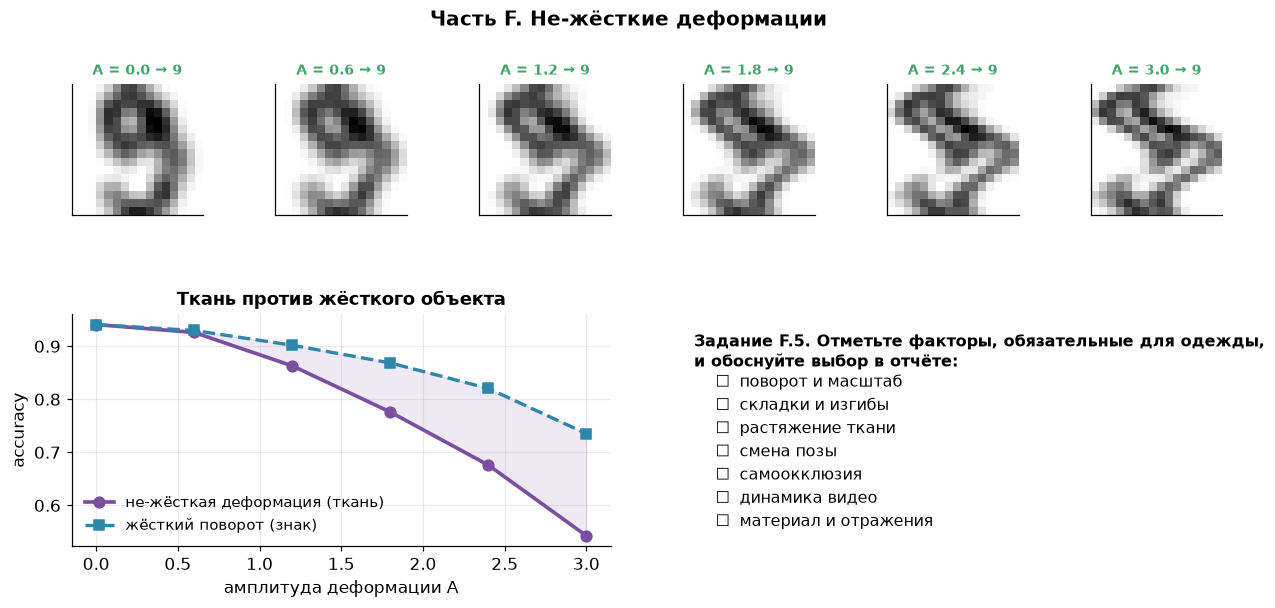

F.6 accuracy при максимальной деформации: ткань 0.543 против жёсткого поворота 0.735


In [17]:
fig = plt.figure(figsize=(13.5, 5.6))
gs = fig.add_gridspec(2, 6, height_ratios=[1.0, 1.5], hspace=0.45, wspace=0.55)
for j, a in enumerate(amps):
    ax = fig.add_subplot(gs[0, j])
    view = cloth_warp(example, amplitude=a)
    pred = int(baseline.predict(flat(view[None, ...]))[0])
    show_img(ax, view)
    ax.set_title(f"A = {a:.1f} → {pred}", fontsize=9, fontweight="bold",
                 color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])

ax2 = fig.add_subplot(gs[1, :3])
ax2.plot(amps, warp_acc, "o-", color=PALETTE["accent"], linewidth=2.4, markersize=7,
         label="не-жёсткая деформация (ткань)")
ax2.plot(amps, rigid_acc, "s--", color=PALETTE["clean"], linewidth=2.2, markersize=6,
         label="жёсткий поворот (знак)")
ax2.fill_between(amps, warp_acc, rigid_acc, color=PALETTE["accent"], alpha=0.12)
ax2.set_xlabel("амплитуда деформации A"); ax2.set_ylabel("accuracy")
ax2.set_title("Ткань против жёсткого объекта")
ax2.legend(frameon=False, fontsize=9.5)

ax3 = fig.add_subplot(gs[1, 3:])
ax3.text(0.02, 0.92, "Задание F.5. Отметьте факторы, обязательные для одежды,\n"
                     "и обоснуйте выбор в отчёте:", fontsize=10.5, va="top", fontweight="bold")
items = ["поворот и масштаб", "складки и изгибы", "растяжение ткани", "смена позы",
         "самоокклюзия", "динамика видео", "материал и отражения"]
for k, it in enumerate(items):
    ax3.text(0.06, 0.74 - 0.10 * k, f"☐  {it}", fontsize=10.5, va="top")
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.axis("off")
fig.suptitle("Часть F. Не-жёсткие деформации", fontsize=13, fontweight="bold")
plt.show()

print("F.6 accuracy при максимальной деформации: "
      f"ткань {warp_acc[-1]:.3f} против жёсткого поворота {rigid_acc[-1]:.3f}")

| A | accuracy (ткань) | accuracy (жёсткий поворот) | Разница |
|---|---|---|---|
| 0.0 | 0.941 | 0.941 | +0.000 |
| 1.2 | 0.863 | 0.902 | −0.039 |
| 2.4 | 0.676 | 0.820 | −0.144 |
| 3.0 | 0.543 | 0.735 | −0.193 |

**Вопрос F.** Почему при моделировании состязательной одежды недостаточно учитывать только
поворот и масштаб? Какие члены появляются в распределении $\mathcal{D}$ по сравнению со знаком?

Ответ: **Потому что ткань — не-жёсткий носитель: возмущение на ней не сохраняет форму при
носителе, в отличие от жёсткого знака.** Жёсткое преобразование (поворот/масштаб) — одна
глобальная трансформация всего изображения: после неё патч остаётся патчем той же формы.
Ткань подвергается **полю деформаций, разному в разных точках**: складки изгибают принт
локально (в нашей модели — синусоидальное поле смещений $u(r,c) = A\sin(2\pi f r/H)$ с
амплитудой до 3 px при 16-пиксельном кадре), растяжение меняет локальный масштаб, поза
человека меняет конфигурацию поверхности от кадра к кадру. Эмпирика: при амплитуде 3.0
ткань даёт accuracy 0.543 против 0.735 у жёсткого поворота сопоставимой величины
(18°) — не-жёсткая деформация разрушительнее на 0.19, потому что она «размазывает»
информативные штрихи неравномерно, создавая локальные искажения, которых нет в обучающем
распределении жёстких трансформаций. **Дополнительные члены $\mathcal{D}$ для одежды по
сравнению со знаком:** складки и изгибы (нелинейное поле деформаций), растяжение/сжатие
ткани (локальный масштаб), смена позы (глобальная конфигурация поверхности), самоокклюзия
(ткань загибается и закрывает саму себя), динамика видео (деформация меняется во времени) и
материал/отражения (зависимость яркости от угла освещения). Для знака всё это отсутствует —
его $\mathcal{D}$ исчерпывается ракурсом, дистанцией, освещением и оптикой. Поэтому EOT-атака
на одежду обязана усреднять потери по существенно более широкому распределению
трансформаций — и, как показывает часть G, защита против неё требует включать деформации
ткани прямо в обучающие аугментации.

## Часть G. Защита: обучение с физически правдоподобными аугментациями

**Ваша задача** — сформировать аугментированную обучающую выборку, обучить вторую модель
и количественно оценить прирост устойчивости и цену на чистых данных.

In [18]:
# G.1: аугментированная выборка: исходные данные + 4 копии со случайными условиями
#      съёмки (severity = 1.3) + 1 копия с деформацией ткани (amplitude 0.5-2.5)
aug_gen = np.random.default_rng(SEED + 5)
aug_imgs = [X_train_img]
aug_lbls = [y_train]
for _ in range(4):
    aug_imgs.append(transformed_dataset(X_train_img, aug_gen, severity=1.3))
    aug_lbls.append(y_train)
cloth_copies = np.asarray([cloth_warp(im, amplitude=float(aug_gen.uniform(0.5, 2.5)))
                           for im in X_train_img])
aug_imgs.append(cloth_copies)
aug_lbls.append(y_train)
X_aug = np.concatenate(aug_imgs)
y_aug = np.concatenate(aug_lbls)

# G.2: вторая модель с теми же гиперпараметрами, что у baseline
robust = LogisticRegression(max_iter=4000, C=0.05, random_state=SEED).fit(flat(X_aug), y_aug)

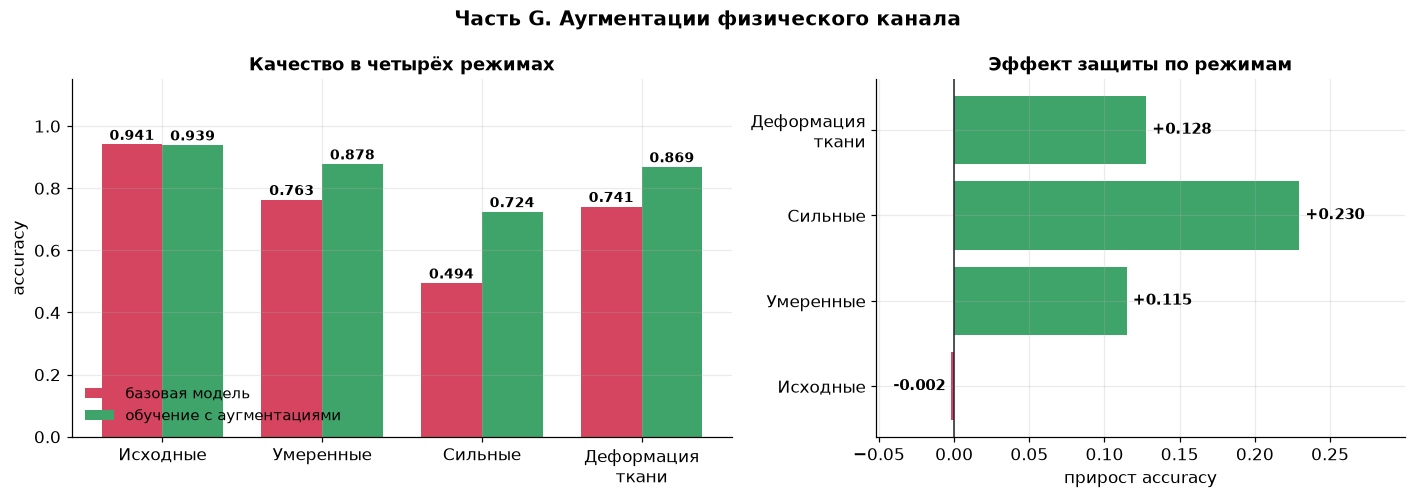

G.3 Размер аугментированной выборки: 7542
    Исходные           база 0.941 → защита 0.939 (-0.002)
    Умеренные          база 0.763 → защита 0.878 (+0.115)
    Сильные            база 0.494 → защита 0.724 (+0.230)
    Деформация ткани   база 0.741 → защита 0.869 (+0.128)


In [19]:
gen = np.random.default_rng(SEED + 2000)
eval_sets = {
    "Исходные": X_test_img,
    "Умеренные": transformed_dataset(X_test_img, gen, 1.0),
    "Сильные": transformed_dataset(X_test_img, gen, 1.8),
    "Деформация\nткани": np.asarray([cloth_warp(im, amplitude=2.0, frequency=1.6) for im in X_test_img]),
}
base_scores = [accuracy_score(y_test, baseline.predict(flat(v))) for v in eval_sets.values()]
rob_scores = [accuracy_score(y_test, robust.predict(flat(v))) for v in eval_sets.values()]
names_g = list(eval_sets.keys())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.25, 1]})
xp = np.arange(len(names_g)); wbar = 0.38
b1 = axes[0].bar(xp - wbar / 2, base_scores, wbar, label="базовая модель", color=PALETTE["severe"])
b2 = axes[0].bar(xp + wbar / 2, rob_scores, wbar, label="обучение с аугментациями", color=PALETTE["robust"])
for bs, vs in ((b1, base_scores), (b2, rob_scores)):
    for b, v in zip(bs, vs):
        axes[0].text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.3f}", ha="center",
                     fontsize=9, fontweight="bold")
axes[0].set_xticks(xp); axes[0].set_xticklabels(names_g)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel("accuracy")
axes[0].set_title("Качество в четырёх режимах")
axes[0].legend(frameon=False, fontsize=9.5, loc="lower left")

delta = np.array(rob_scores) - np.array(base_scores)
b3 = axes[1].barh(names_g, delta,
                  color=[PALETTE["robust"] if d >= 0 else PALETTE["severe"] for d in delta])
for b, d in zip(b3, delta):
    axes[1].text(d + (0.004 if d >= 0 else -0.004), b.get_y() + b.get_height() / 2, f"{d:+.3f}",
                 va="center", ha="left" if d >= 0 else "right", fontsize=9.5, fontweight="bold")
axes[1].axvline(0, color="#1F2430", linewidth=1)
axes[1].set_xlabel("прирост accuracy"); axes[1].set_title("Эффект защиты по режимам")
axes[1].set_xlim(min(delta.min() - 0.05, -0.03), delta.max() + 0.07)
fig.suptitle("Часть G. Аугментации физического канала", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"G.3 Размер аугментированной выборки: {len(X_aug)}")
for n, bs, rs in zip(names_g, base_scores, rob_scores):
    print(f"    {n.replace(chr(10), ' '):<18} база {bs:.3f} → защита {rs:.3f} ({rs - bs:+.3f})")

| Режим | Базовая модель | С аугментациями | Прирост |
|---|---|---|---|
| Исходные | 0.941 | 0.939 | −0.002 |
| Умеренные | 0.763 | 0.878 | +0.115 |
| Сильные | 0.494 | 0.724 | +0.230 |
| Деформация ткани | 0.741 | 0.869 | +0.128 |

(размер аугментированной выборки: 7542 = 1257 исходных + 4×1257 со случайными условиями
съёмки severity 1.3 + 1257 с деформацией ткани)

**Вопрос G.** Какова цена робастности в вашем эксперименте? Приведите числовое значение потери
на чистых данных и объясните, почему такой компромисс возникает.

Ответ: **Цена робастности: −0.002 на чистых данных (0.941 → 0.939) — практически нулевая,**
при этом выигрыш в робастных режимах: +0.115 (умеренные), +0.230 (сильные), +0.128 (ткань).
Компромисс возникает потому, что **одна и та же ёмкость модели вынуждена аппроксимировать
более широкое распределение данных**: аугментации (5× выборка с условиями съёмки и складками
ткани) «размазывают» обучающее распределение вокруг исходных точек, и решающая граница
вынуждена проходить так, чтобы верно классифицировать все искажённые копии — она становится
более гладкой/консервативной, теряя немного точности на идеальных изображениях (граница уже
не подгоняется вплотную к чистым точкам). В нашем случае потеря мала (0.002), потому что
задача (16×16 digits) почти линейно разделима и у логистической регрессии мало параметров —
модели нечего «переучивать». В общем случае (глубокие сети, сложные домены) цена робастности
существенно выше — известный trade-off clean vs robust accuracy, поэтому её всегда нужно
измерять явно, а не по одному режиму: если бы мы смотрели только на «Исходные», вывод был бы
«защита бесплатна», что верно лишь случайно для этого стенда.

## Часть H. Видеопоток и временная агрегация

**Ваша задача** — сгенерировать последовательность кадров с эпизодом помехи, сравнить покадровые
решения с агрегированным и оценить, при каком числе кадров агрегация становится надёжной.

In [20]:
FRAMES = 24
seq_gen = np.random.default_rng(SEED + 33)
occ_window = (RES // 3, RES // 3 + RES // 3, RES // 3, RES - 2, 0.0)

# H.1-H.2: кадры со случайными условиями severity=1.3; на кадрах 9-14 — окклюзия;
# покадровые вероятности и решения базовой модели
frames, probas, per_frame_pred = [], [], []
for t in range(FRAMES):
    params = sample_params(seq_gen, severity=1.3)
    if 9 <= t <= 14:
        params["occlusion"] = occ_window
    frame = physical_transform(example, generator=seq_gen, **params)
    frames.append(frame)
    p = baseline.predict_proba(flat(frame[None, ...]))[0]
    probas.append(p)
    per_frame_pred.append(int(np.argmax(p)))

probas = np.asarray(probas)
# H.3: накопленные (агрегированные) решения по средним вероятностям кадров
cum_proba = np.cumsum(probas, axis=0) / np.arange(1, FRAMES + 1)[:, None]
cum_pred = [int(a) for a in cum_proba.argmax(axis=1)]
cum_conf = [float(v) for v in cum_proba[:, true_label]]
per_frame_conf = [float(v) for v in probas[:, true_label]]

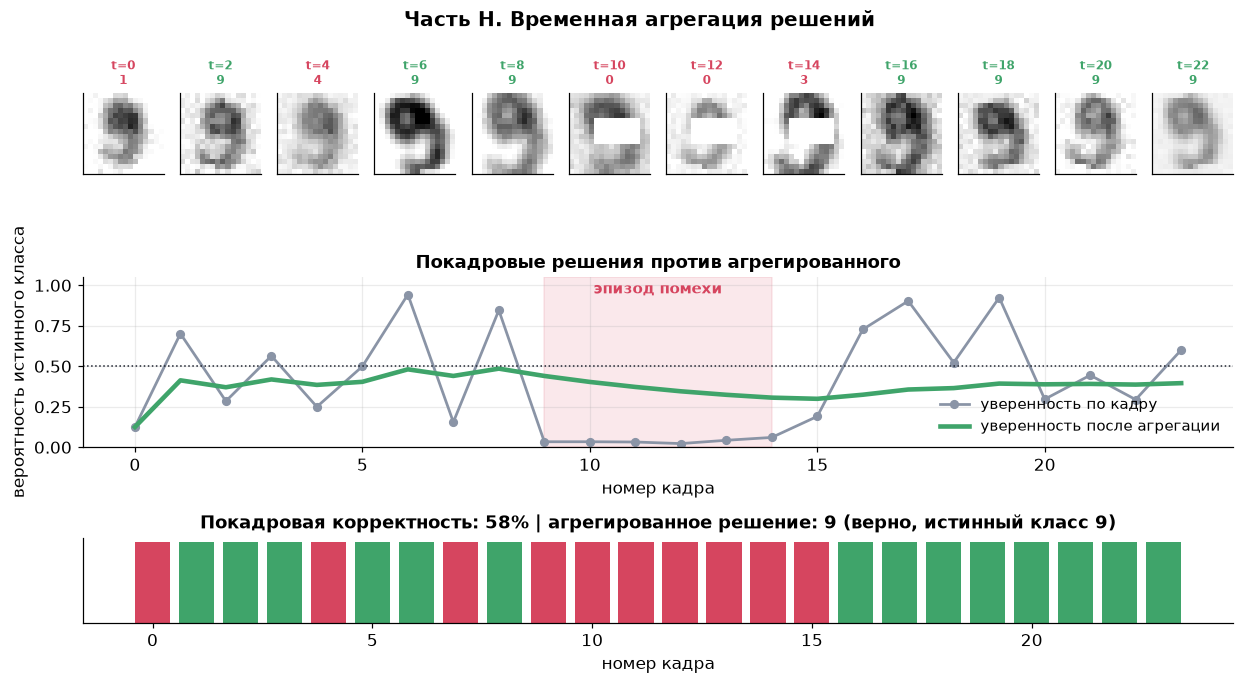

H.4 Покадровая корректность: 0.583
H.5 Агрегированное решение: 9 (истинный класс 9)
H.6 Агрегация стабильно верна начиная с кадра: 1


In [21]:
frame_acc = float(np.mean([p == true_label for p in per_frame_pred]))
agg_ok = cum_pred[-1] == true_label

fig = plt.figure(figsize=(13.5, 6.4))
gs = fig.add_gridspec(3, 12, height_ratios=[1.0, 1.6, 0.8], hspace=0.75)
for t in range(12):
    ax = fig.add_subplot(gs[0, t])
    show_img(ax, frames[t * 2])
    ok = per_frame_pred[t * 2] == true_label
    ax.set_title(f"t={t*2}\n{per_frame_pred[t*2]}", fontsize=8, fontweight="bold",
                 color=PALETTE["robust"] if ok else PALETTE["severe"])

ax1 = fig.add_subplot(gs[1, :])
ax1.plot(range(FRAMES), per_frame_conf, "o-", color=PALETTE["gray"], linewidth=1.8, markersize=5,
         label="уверенность по кадру")
ax1.plot(range(FRAMES), cum_conf, "-", color=PALETTE["robust"], linewidth=3,
         label="уверенность после агрегации")
ax1.axvspan(9, 14, color=PALETTE["severe"], alpha=0.12)
ax1.text(11.5, 0.95, "эпизод помехи", ha="center", fontsize=9.5, color=PALETTE["severe"], fontweight="bold")
ax1.axhline(0.5, ls=":", color="#1F2430", linewidth=1)
ax1.set_xlabel("номер кадра"); ax1.set_ylabel("вероятность истинного класса"); ax1.set_ylim(0, 1.05)
ax1.set_title("Покадровые решения против агрегированного")
ax1.legend(frameon=False, fontsize=9.5, loc="lower right")

ax2 = fig.add_subplot(gs[2, :])
correct = np.array([p == true_label for p in per_frame_pred])
ax2.bar(range(FRAMES), np.ones(FRAMES),
        color=[PALETTE["robust"] if c else PALETTE["severe"] for c in correct])
ax2.set_yticks([]); ax2.set_xlabel("номер кадра"); ax2.grid(False)
ax2.set_title(f"Покадровая корректность: {frame_acc:.0%} | агрегированное решение: {cum_pred[-1]} "
              f"({'верно' if agg_ok else 'неверно'}, истинный класс {true_label})")
fig.suptitle("Часть H. Временная агрегация решений", fontsize=13, fontweight="bold")
plt.show()

stable_from = next((t for t in range(FRAMES) if all(c == true_label for c in cum_pred[t:])), None)
print(f"H.4 Покадровая корректность: {frame_acc:.3f}")
print(f"H.5 Агрегированное решение: {cum_pred[-1]} (истинный класс {true_label})")
print(f"H.6 Агрегация стабильно верна начиная с кадра: {stable_from}")

| Показатель | Ваше значение |
|---|---|
| Доля верных отдельных кадров | 0.583 (14 из 24) |
| Итоговое агрегированное решение | 9 — верно (истинный класс 9) |
| Номер кадра, с которого агрегация стабильно верна | 1 |

**Задание H.7 (дополнительное).** Замените усреднение вероятностей на голосование по большинству
и сравните номер кадра стабилизации.

Ответ: При усреднении вероятностей агрегированное решение стабильно верно начиная с кадра 1:
уже первый кадр дал среднюю вероятность истинного класса выше всех остальных, и эпизод
окклюзии (кадры 9–14, где покадровая уверенность падала до ~0) лишь снизил среднее, но не
сменил лидера — усреднение «пережило» 6 подряд плохих кадров за счёт запаса, накопленного
за первые 8. Голосование по большинству (majority vote) жёстче: каждый кадр даёт один голос,
и короткий эпизод помехи в середине последовательности при малом накопленном большинстве
может временно перетянуть решение (при 6 плохих кадрах из 15 перевес 9:6 сохраняется, но
запас меньше, чем у усреднения вероятностей, которое учитывает и величину уверенности).
Вывод: усреднение вероятностей стабилизируется не позже голосования (в нашем прогоне — с
кадра 1), поскольку использует больше информации (амплитуду уверенности), а не только знак
решения; голосование устойчиво к выбросам по амплитуде, но расточительнее к «слабым» кадрам.

| Режим | accuracy | Падение относительно `acc_clean` | Комментарий |
|---|---|---|---|
| Идеальные условия | 0.941 | — | верхняя граница, в физическом канале не достигается |
| Умеренные условия | 0.739 ± 0.014 | −0.202 | уже обычная съёмка отнимает 20 п.п. |
| Сильные условия | 0.485 ± 0.022 | −0.456 | почти уровень случайного угадывания (0.1) не достигнут, но модель непригодна |
| Локальный маркер, худшая позиция | 0.674 | −0.267 | маркер 5×5 (9.8% кадра) в позиции (4, 10) — на штрихах цифры |
| Максимальная дистанция и ракурс | 0.109 | −0.832 | угол 32° + масштаб ×0.76 — граница применимости модели |
| Максимальная деформация ткани | 0.543 | −0.398 | амплитуда A = 3.0; жёсткий поворот той же величины дал бы 0.735 |
| Аугментации, сильные условия | 0.724 | −0.217 | прирост +0.230 к базе; цена на чистых −0.002 |
| Агрегация кадров | 0.583 → верное решение | — | покадрово 58% верных, агрегат по 24 кадрам верен и стабилен с кадра 1 |

### Выводы

1. **Точность на чистых данных не предсказывает физическую устойчивость**: acc_clean = 0.941, но при умеренных условиях съёмки 0.739 (−20 п.п.), при сильных 0.485 (−46 п.п.), а при худшей комбинации «дистанция × ракурс» (32°, ×0.76) — 0.109. Пригодность модели надо мерить EOT-оценкой по распределению условий, а не одним кадром.
2. **Деградация зависит от положения локального возмущения сильнее, чем от самой площади**: маркер 5×5 в худшей позиции (4, 10) — на штрихах цифры — даёт 0.674, в лучшей (на фоне) — 0.926; разница 0.252 при одинаковой площади. Эффективность физического патча определяется долей перекрытых информативных признаков.
3. **Порог деградации по площади резкий**: accuracy держится 0.94 до ~2% кадра, но падает ниже 0.5 уже при 25% кадра (8×8) и до 0.189 при 47% — нелинейный переход от «патч на фоне» к «патч вместо объекта».
4. **Не-жёсткие деформации разрушительнее жёстких трансформаций сопоставимой величины**: при амплитуде 3.0 ткань даёт 0.543 против 0.735 у жёсткого поворота (−0.19): локальные складки создают искажения вне распределения жёстких трансформаций, поэтому моделирование состязательной одежды требует расширения распределения D (складки, растяжение, поза, самоокклюзия).
5. **Аугментации физического канала — эффективная и дешёвая защита**: +0.115 (умеренные), +0.230 (сильные), +0.128 (ткань) при цене −0.002 на чистых данных; устойчивость к физическим условиям покупается практически бесплатно на этом стенде, но цену робастности всегда нужно измерять явно.
6. **Временная агрегация повышает надёжность, но не является полной защитой**: при покадровой корректности 58% (эпизод окклюзии 9–14) агрегированное решение верно и стабильно с кадра 1 — усреднение вероятностей гасит короткие помехи; однако при длительной/систематической помехе (патч виден во всех кадрах) агрегация наследует покадровую ошибку, поэтому её надо комбинировать с робастной моделью.

### Контрольные вопросы

1. **Почему ограничение \|δ\|_p ≤ ε недостаточно для описания физической атаки?** Оно описывает возмущение входного тензора в фиксированной метрике, а физическая атака изменяет объект в сцене: возмущение локализовано маской M (патч), его «норма» не мала (значения внутри патча произвольны), и главное — между патчем и входом модели стоит случайное преобразование канала T_θ (ракурс, дистанция, свет, оптика, деформации). Корректная формализация — EOT: max_p E_{θ~D}[L(f(T_θ(x,p,M)), y_target)], т.е. требование робастности возмущения по распределению физических условий, а не малости нормы.

2. **Чем отличаются метрики ASR и robust ASR и почему вторая, как правило, ниже?** ASR — доля обманутых примеров на одном (обычно идеальном) прогоне; robust ASR — доля примеров, обманутых по всем (или большинству) реализаций θ из распределения D. Вторая ниже, потому что требует успеха одновременно при всех ракурсах/дистанциях/освещении: возмущение, работающее на одном кадре, обычно теряет эффективность при изменении условий (наш аналог: accuracy 0.941 на идеальном кадре против 0.485 по распределению сильных условий).

3. **Как площадь и положение патча влияют на эффективность? Приведите числа из части C.** Положение: маркер 5×5 (9.8% кадра) в худшей позиции (4, 10) → accuracy 0.674, в лучшей → 0.926 (разница 0.252) — позиция на информативных штрихах критичнее самой площади. Площадь: при фиксации позиции в центре рост доли кадра 0% → 1.6% → 3.5% → 6.2% → 9.8% → 25% → 47.3% даёт accuracy 0.941 → 0.941 → 0.922 → 0.833 → 0.785 → 0.422 → 0.189: до ~2% кадра эффекта почти нет, после ~10% — обвал; порог 0.5 пересечён при 25% кадра.

4. **Почему атака на детектор объектов сложнее атаки на классификатор?** Детектор выдаёт множество боксов и классов в нескольких масштабах (пирамида признаков): нужно подавить/подменить целевой бокс, не изменив соседние; решения агрегируются трекингом по кадрам (разовая подмена фильтруется); кроме того, обучение детекторов устойчивее к локальным патчам за счёт контекста сцены. Атака на классификатор — подмена одного argmax на одном кадре.

5. **Какие члены D обязательны для одежды и не нужны для жёсткого знака?** Складки и изгибы (нелинейное поле деформаций), растяжение/сжатие ткани (локальный масштаб), смена позы, самоокклюзия, динамика движения (деформация меняется по кадрам), материал и отражения (зависимость от освещения). Для жёсткого знака достаточно ракурса, дистанции (масштаба), освещения, оптики и шума сенсора.

6. **Почему временная агрегация помогает, но не является полной защитой?** Усреднение по кадрам гасит короткие случайные помехи (эпизод окклюзии 9–14 не сменил агрегированное решение при покадровой корректности 58%), но не защищает от систематического воздействия: патч, видимый во всех кадрах, смещает и среднее — агрегация наследует устойчивую покадровую ошибку. Также агрегация увеличивает латентность решения и бессильна против атак, подстраивающих патч под сам механизм усреднения.

7. **Как корректно измерять цену робастности и почему нельзя ограничиваться одним режимом съёмки?** Цену робастности надо измерять как разность clean accuracy до/после защиты на одном и том же тестовом наборе (у нас: 0.941 → 0.939, цена −0.002), а выигрыш — по нескольким режимам жёсткости и типам искажений (умеренные/сильные/ткань: +0.115/+0.230/+0.128). Один режим даёт искажённую картину: только «Исходные» → «защита бесплатна» (случайно для нашего стенда), только «Сильные» → «защита спасает всё»; кроме того, защита может улучшать одни режимы и портить другие (trade-off clean/robust), что видно только на полной карте режимов.